# Relative Error Metrics Study

The heatmap from `visualize_results.py` shows 100,000%+ relative errors for axial (X+/X-) cases.
This is a **metric problem**, not a model problem.

The current formula:
```python
denom = np.abs(true - true.min()).mean() + 1e-12
rel_err = mae / denom * 100
```

For axial displacement U1 ≈ 0.001 mm → denom ≈ 0.001 → rel_err explodes.

We study 5 candidate metrics here and pick the best one.

In [1]:
import sys
import json
import numpy as np
import torch
import meshio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))
from arch import BeamNet

ROOT      = Path('..')
CCX_CASES = ROOT / 'ccx_cases' / 'elasticity_axial_beam'
SAVES     = ROOT / 'saves'

LOG_COLS = [6]
DIR_MAP  = {
    'Y' : np.array([0., 1., 0.]),
    'Z' : np.array([0., 0., -1.]),
    'YZ': np.array([0., 0.707, 0.707]),
    'X' : np.array([-1., 0., 0.]),
    'X+': np.array([1., 0., 0.]),
    'X-': np.array([-1., 0., 0.]),
}

In [2]:
# ── Load model & norm params ───────────────────────────────────────────────
ckpt = torch.load(SAVES / 'beam_pinn.pt', map_location='cpu', weights_only=True)
model = BeamNet(hidden=ckpt['hidden'])
state_dict = ckpt['model_state']
if any(k.startswith('module.') for k in state_dict):
    state_dict = {k[len('module.'):]: v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.eval()

norm = dict(np.load(SAVES / 'norm_params.npz'))
print('Y_mean:', norm['Y_mean'])
print('Y_std :', norm['Y_std'])

Y_mean: [-1.0297165e-03 -4.6572480e-03 -5.8139272e+00]
Y_std : [ 1.4468371   0.02164161 18.1515    ]


In [3]:
# ── Run inference on all test cases ───────────────────────────────────────
def predict_case(entry):
    vtu_path = CCX_CASES / entry['vtu']
    params   = json.loads((vtu_path.parent / 'case_params.json').read_text())
    mesh     = meshio.read(str(vtu_path))
    coords   = mesh.points.astype(np.float32)
    true_mm  = mesh.point_data['displacement'].astype(np.float32)  # (N, 3)
    N = len(coords)

    force_dir  = DIR_MAP[params['load_dir']]
    case_feats = np.array([*force_dir, params['force_N'], params['E_MPa'], params['nu']], dtype=np.float32)
    X = np.hstack([coords, np.tile(case_feats, (N, 1))])

    X_p = X.copy()
    for c in LOG_COLS:
        X_p[:, c] = np.log(X_p[:, c])
    X_n = ((X_p - norm['X_mean']) / norm['X_std']).astype(np.float32)

    with torch.no_grad():
        Y_n = model(torch.from_numpy(X_n)).numpy()
    pred_mm = Y_n * norm['Y_std'] + norm['Y_mean']

    return pred_mm, true_mm, params

manifest = json.loads((CCX_CASES / 'vtk_manifest.json').read_text())
test_entries = [e for e in manifest['cases'] if e.get('split') == 'test' and e.get('success')]
print(f'{len(test_entries)} test cases')

results = []
for entry in test_entries:
    pred, true, params = predict_case(entry)
    mae = np.abs(pred - true).mean(axis=0)          # (3,) per component
    rmse = np.sqrt(((pred - true)**2).mean(axis=0)) # (3,)
    results.append({'params': params, 'pred': pred, 'true': true, 'mae': mae, 'rmse': rmse})

print('Done')

75 test cases


Done


## Candidate metrics

| # | Name | Formula | Strength | Weakness |
|---|------|---------|----------|----------|
| A | Current | `MAE / mean(|u - u_min|)` | Per-component normalisation | Explodes when displacement range is tiny |
| B | Range-based | `MAE / (max(|u|) - min(|u|) + ε)` | Robust denominator | Still blows up for near-zero range |
| C | RMS-based | `RMSE / RMS(true)` | Scale-free, standard in FEM validation | Undefined when RMS ≈ 0 |
| D | Vector norm | `mean(‖pred - true‖₂) / mean(‖true‖₂)` | Single number, direction-agnostic | Axial swamped by bending |
| E | Max displacement | `MAE_component / max(‖true‖₂)` | One reference for all components | Favours small components |

In [4]:
def metric_A(mae, true):   # current
    denom = np.abs(true - true.min(axis=0)).mean(axis=0) + 1e-12
    return mae / denom * 100

def metric_B(mae, true):   # range-based
    denom = (np.abs(true).max(axis=0) - np.abs(true).min(axis=0)) + 1e-6
    return mae / denom * 100

def metric_C(rmse, true):  # RMS-based
    denom = np.sqrt((true**2).mean(axis=0)) + 1e-6
    return rmse / denom * 100

def metric_D(pred, true):  # vector norm
    diff_norm = np.linalg.norm(pred - true, axis=1).mean()
    true_norm = np.linalg.norm(true, axis=1).mean() + 1e-6
    return diff_norm / true_norm * 100

def metric_E(mae, true):   # max displacement reference
    ref = np.linalg.norm(true, axis=1).max() + 1e-6
    return mae / ref * 100

# Compute all metrics for each test case
for r in results:
    r['A'] = metric_A(r['mae'], r['true'])
    r['B'] = metric_B(r['mae'], r['true'])
    r['C'] = metric_C(r['rmse'], r['true'])
    r['D'] = metric_D(r['pred'], r['true'])
    r['E'] = metric_E(r['mae'], r['true'])

print('Metrics computed')

Metrics computed


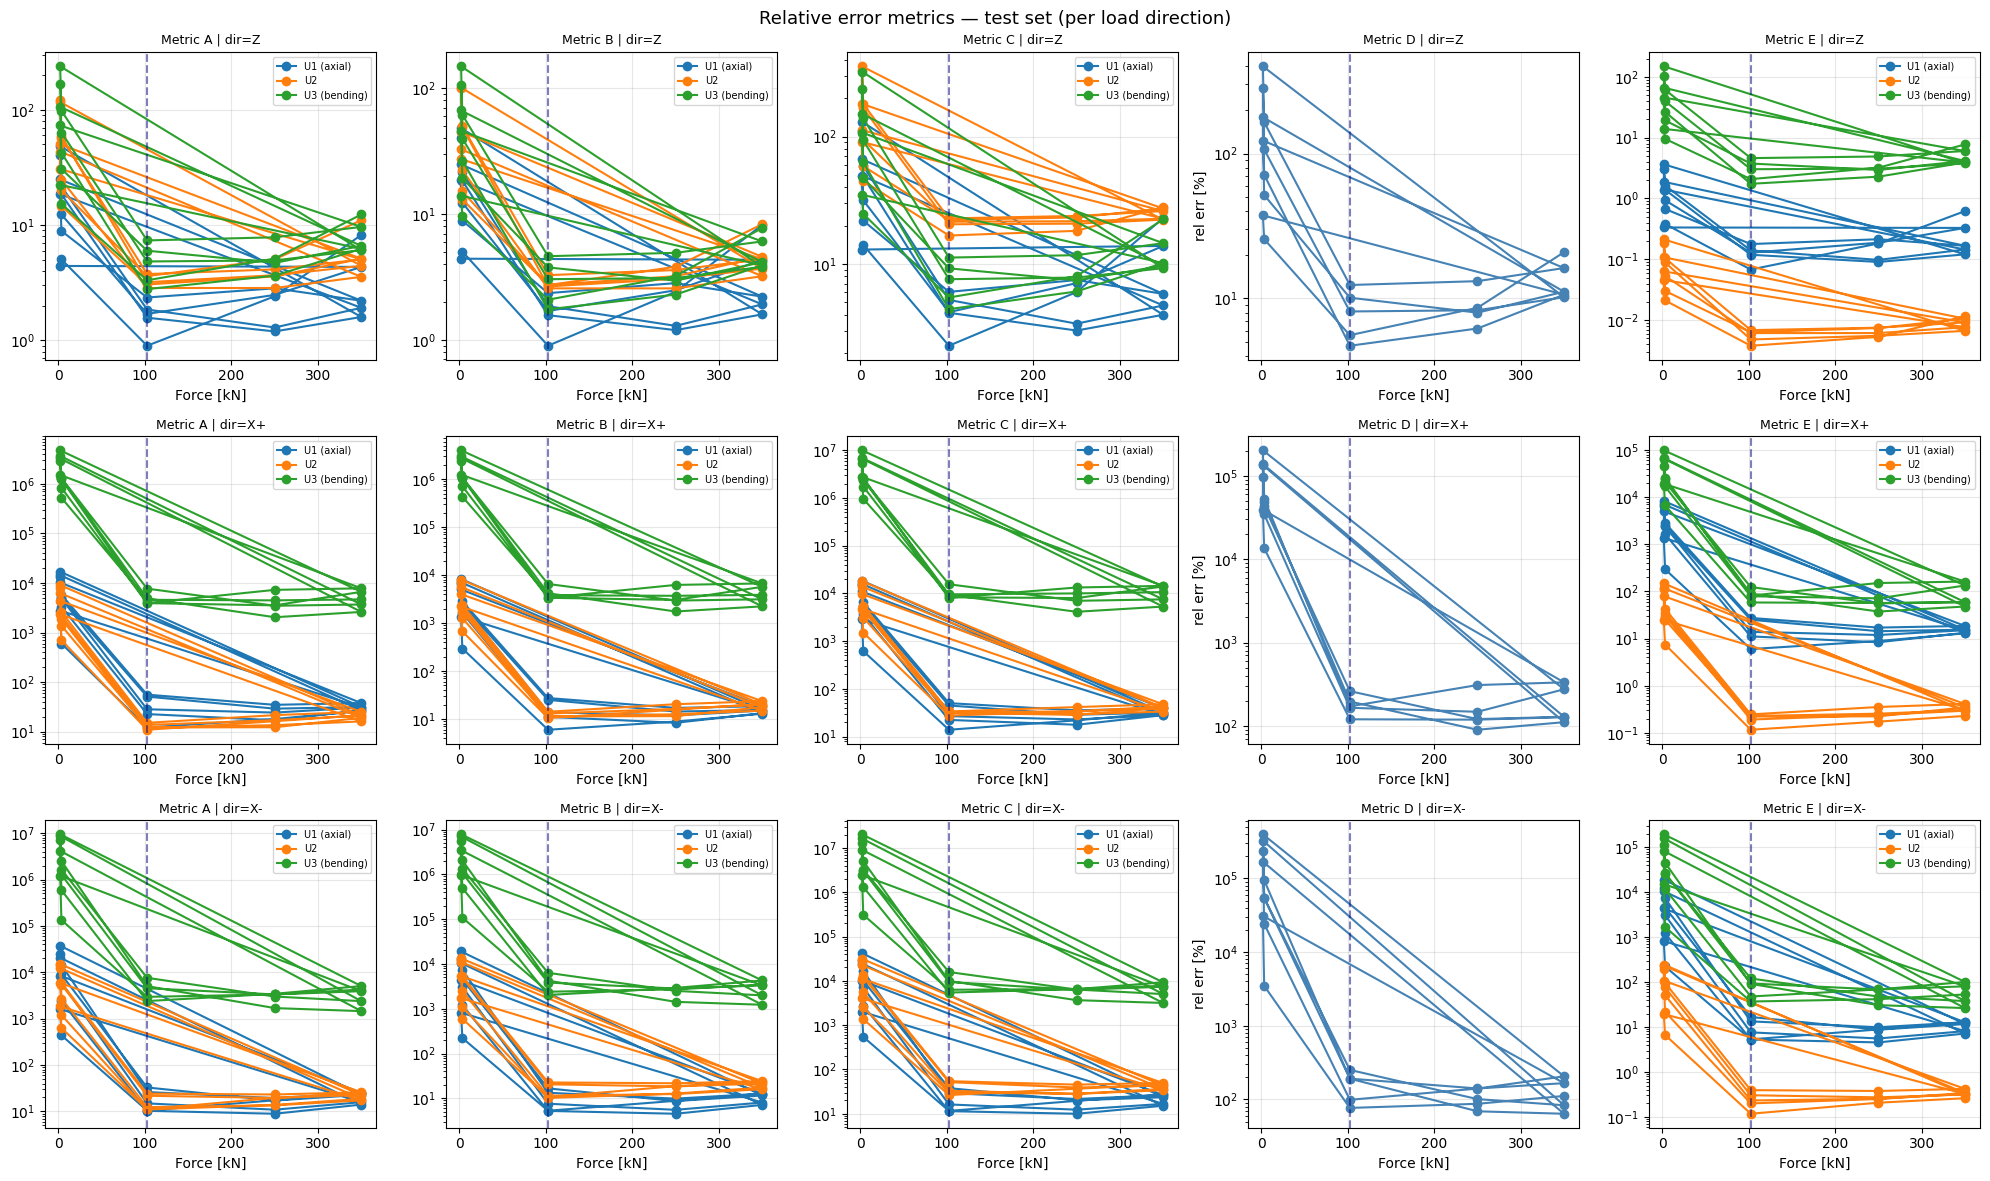

Saved metric_comparison.png


In [5]:
# ── Compare metrics side by side for each load direction ──────────────────
METRICS   = ['A', 'B', 'C', 'D', 'E']
DIRS      = ['Z', 'X+', 'X-']
COMP_NAMES = ['U1 (axial)', 'U2', 'U3 (bending)']

fig, axes = plt.subplots(len(DIRS), len(METRICS), figsize=(20, 12))
fig.suptitle('Relative error metrics — test set (per load direction)', fontsize=13)

for row, d in enumerate(DIRS):
    cases = [r for r in results if r['params']['load_dir'] == d]
    forces = [r['params']['force_N'] / 1000 for r in cases]

    for col, m in enumerate(METRICS):
        ax = axes[row, col]
        if m == 'D':
            vals = [r[m] for r in cases]  # scalar
            ax.plot(forces, vals, 'o-', color='steelblue')
            ax.set_ylabel('rel err [%]')
        else:
            for ic, cname in enumerate(COMP_NAMES):
                vals = [r[m][ic] for r in cases]
                ax.plot(forces, vals, 'o-', label=cname)
            ax.legend(fontsize=7)

        ax.set_title(f'Metric {m} | dir={d}', fontsize=9)
        ax.set_xlabel('Force [kN]')
        ax.set_yscale('log')
        ax.axvline(x=102.5, color='navy', linestyle='--', alpha=0.5, label='train min')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVES / 'metric_comparison.png', dpi=120)
plt.show()
print('Saved metric_comparison.png')

In [6]:
# ── Print summary table for a quick read ──────────────────────────────────
print(f"{'Case':<12} {'Dir':<4} {'F[kN]':>8}  {'A(U1)':>10} {'B(U1)':>10} {'C(U1)':>10} {'D':>10} {'E(U1)':>10}  MAE_U1[mm]")
print('-' * 100)
for r in sorted(results, key=lambda x: (x['params']['load_dir'], x['params']['force_N'])):
    p = r['params']
    print(
        f"{p['case_id']:<12} {p['load_dir']:<4} {p['force_N']/1000:>8.1f}  "
        f"{r['A'][0]:>10.1f} {r['B'][0]:>10.1f} {r['C'][0]:>10.1f} "
        f"{r['D']:>10.1f} {r['E'][0]:>10.1f}  {r['mae'][0]:.4f}"
    )

Case         Dir     F[kN]       A(U1)      B(U1)      C(U1)          D      E(U1)  MAE_U1[mm]
----------------------------------------------------------------------------------------------------
case_1505    X+        2.0     13008.0     6382.8    15039.5    96275.3     6382.6  0.0626
case_1520    X+        2.0     16865.5     8265.3    18501.0   138521.4     8265.1  0.0771
case_1535    X+        2.0     10215.2     5004.6    10980.7   134443.8     5004.5  0.1419
case_1550    X+        2.0     14337.4     7019.8    15849.8   202247.9     7019.6  0.1205
case_1565    X+        2.0      2765.0     1359.8     2857.3    39206.1     1359.8  0.0808
case_1506    X+        3.5      4954.8     2432.3     5553.0    43255.2     2432.2  0.0417
case_1521    X+        3.5      5764.0     2826.1     6498.6    48864.6     2826.0  0.0461
case_1536    X+        3.5      3335.3     1634.3     3631.5    34600.8     1634.2  0.0811
case_1551    X+        3.5      4866.7     2383.4     5404.7    52733.9     

## Decision

Fill in after running the notebook.

- **Metric A** (current): bad for near-zero displacements (axial cases)
- **Metric B**: similar issue
- **Metric C** (RMS-based): standard in FEM literature, handles near-zero better
- **Metric D** (vector norm): single number, clean but hides per-component info
- **Metric E** (max displacement reference): intuitive — "error as % of max deformation in the structure"

→ Pick your preferred metric and update `visualize_results.py`.

---
## New metrics F–J — addressing the root cause

The problem with A–E is not the formula — it is the assumption that a single per-component relative error can work across load directions where different components are physically near-zero.

Five new approaches, each attacking the problem differently:

| # | Name | Key idea | Avoids near-zero? |
|---|------|----------|-------------------|
| F | R² per component | Scale-free, no MAE/denominator division | Mostly yes |
| G | Energy norm (L2 vector) | Normalise the full 3D field at once | Yes |
| H | Dominant-component reference | Use the biggest component as reference for all | Yes |
| I | Tip displacement error | Only look at x=L where displacement is always large | Yes |
| J | Pointwise vector with floor | Per-node vector error, floor at 1% of peak | Yes |

In [7]:
def metric_F(pred, true):
    """
    R² (coefficient of determination) per component.
    R² = 1 - SS_res / SS_tot
    Range: (-inf, 1].  1 = perfect,  0 = no better than predicting the mean,  negative = bad.
    Does not divide by MAE — the denominator is the variance of the true field,
    which is near-zero only if the entire component is perfectly uniform (physically degenerate).
    Reported as error = (1 - R²) × 100  so that 0% = perfect, like the other metrics.
    """
    ss_res = ((pred - true) ** 2).sum(axis=0)           # (3,)
    ss_tot = ((true - true.mean(axis=0)) ** 2).sum(axis=0) + 1e-12
    r2 = 1.0 - ss_res / ss_tot
    return (1.0 - r2) * 100   # (3,)  — lower is better, like rel-err


def metric_G(pred, true):
    """
    Energy norm — L2 relative error of the full 3D displacement field.
    η = sqrt( Σ‖pred_i - true_i‖² / Σ‖true_i‖² )
    Single scalar per case.  Standard in FEM error analysis.
    Denominator is the total field energy — zero only if all displacements are zero.
    """
    num = np.sum((pred - true) ** 2)
    den = np.sum(true ** 2) + 1e-12
    return np.sqrt(num / den) * 100   # scalar [%]


def metric_H(pred, true):
    """
    Dominant-component reference.
    Find the component with the largest RMS (the 'active' direction for this load case),
    use its RMS as the reference for ALL three components.
    Automatically adapts to load direction:
      Z-load  → reference = RMS(U3)
      X-load  → reference = RMS(U1)
    """
    rms_per_comp = np.sqrt((true ** 2).mean(axis=0))   # (3,)
    dominant_rms = rms_per_comp.max() + 1e-6
    mae = np.abs(pred - true).mean(axis=0)             # (3,)
    return mae / dominant_rms * 100   # (3,)


def metric_I(pred, true, coords):
    """
    Tip displacement relative error.
    For a beam loaded at x=L, the tip (x=L face) always has the largest displacement.
    Select nodes at x ≈ max(x), compute ‖pred - true‖₂ / ‖true‖₂ at those nodes.
    Single scalar per case — physically the most meaningful metric for a beam.
    """
    x_max = coords[:, 0].max()
    tip_mask = coords[:, 0] > (x_max - 1.0)           # nodes within 1mm of tip
    pred_tip = pred[tip_mask]
    true_tip = true[tip_mask]
    err = np.linalg.norm(pred_tip - true_tip, axis=1).mean()
    ref = np.linalg.norm(true_tip, axis=1).mean() + 1e-6
    return err / ref * 100   # scalar [%]


def metric_J(pred, true):
    """
    Pointwise vector error with floor.
    For each node: ‖pred_i - true_i‖₂ / max(‖true_i‖₂, ε)
    where ε = 1% of the peak displacement magnitude in this case.
    Avoids explosion at near-zero nodes while staying per-node meaningful.
    Single scalar per case (mean over nodes).
    """
    peak = np.linalg.norm(true, axis=1).max()
    floor = 0.01 * peak + 1e-6
    err_per_node = np.linalg.norm(pred - true, axis=1)
    ref_per_node = np.maximum(np.linalg.norm(true, axis=1), floor)
    return (err_per_node / ref_per_node).mean() * 100   # scalar [%]


print('Metrics F–J defined.')

Metrics F–J defined.


In [8]:
# ── Need coords for metric I — reload cases with coordinates ──────────────────
results2 = []
for entry in test_entries:
    pred, true, params = predict_case(entry)
    vtu_path = CCX_CASES / entry['vtu']
    mesh     = meshio.read(str(vtu_path))
    coords   = mesh.points.astype(np.float32)
    mae      = np.abs(pred - true).mean(axis=0)
    rmse     = np.sqrt(((pred - true)**2).mean(axis=0))

    results2.append({
        'params': params,
        'pred': pred, 'true': true, 'coords': coords,
        'mae': mae, 'rmse': rmse,
        'F': metric_F(pred, true),
        'G': metric_G(pred, true),
        'H': metric_H(pred, true),
        'I': metric_I(pred, true, coords),
        'J': metric_J(pred, true),
    })

print(f'Done — {len(results2)} cases.')

Done — 75 cases.


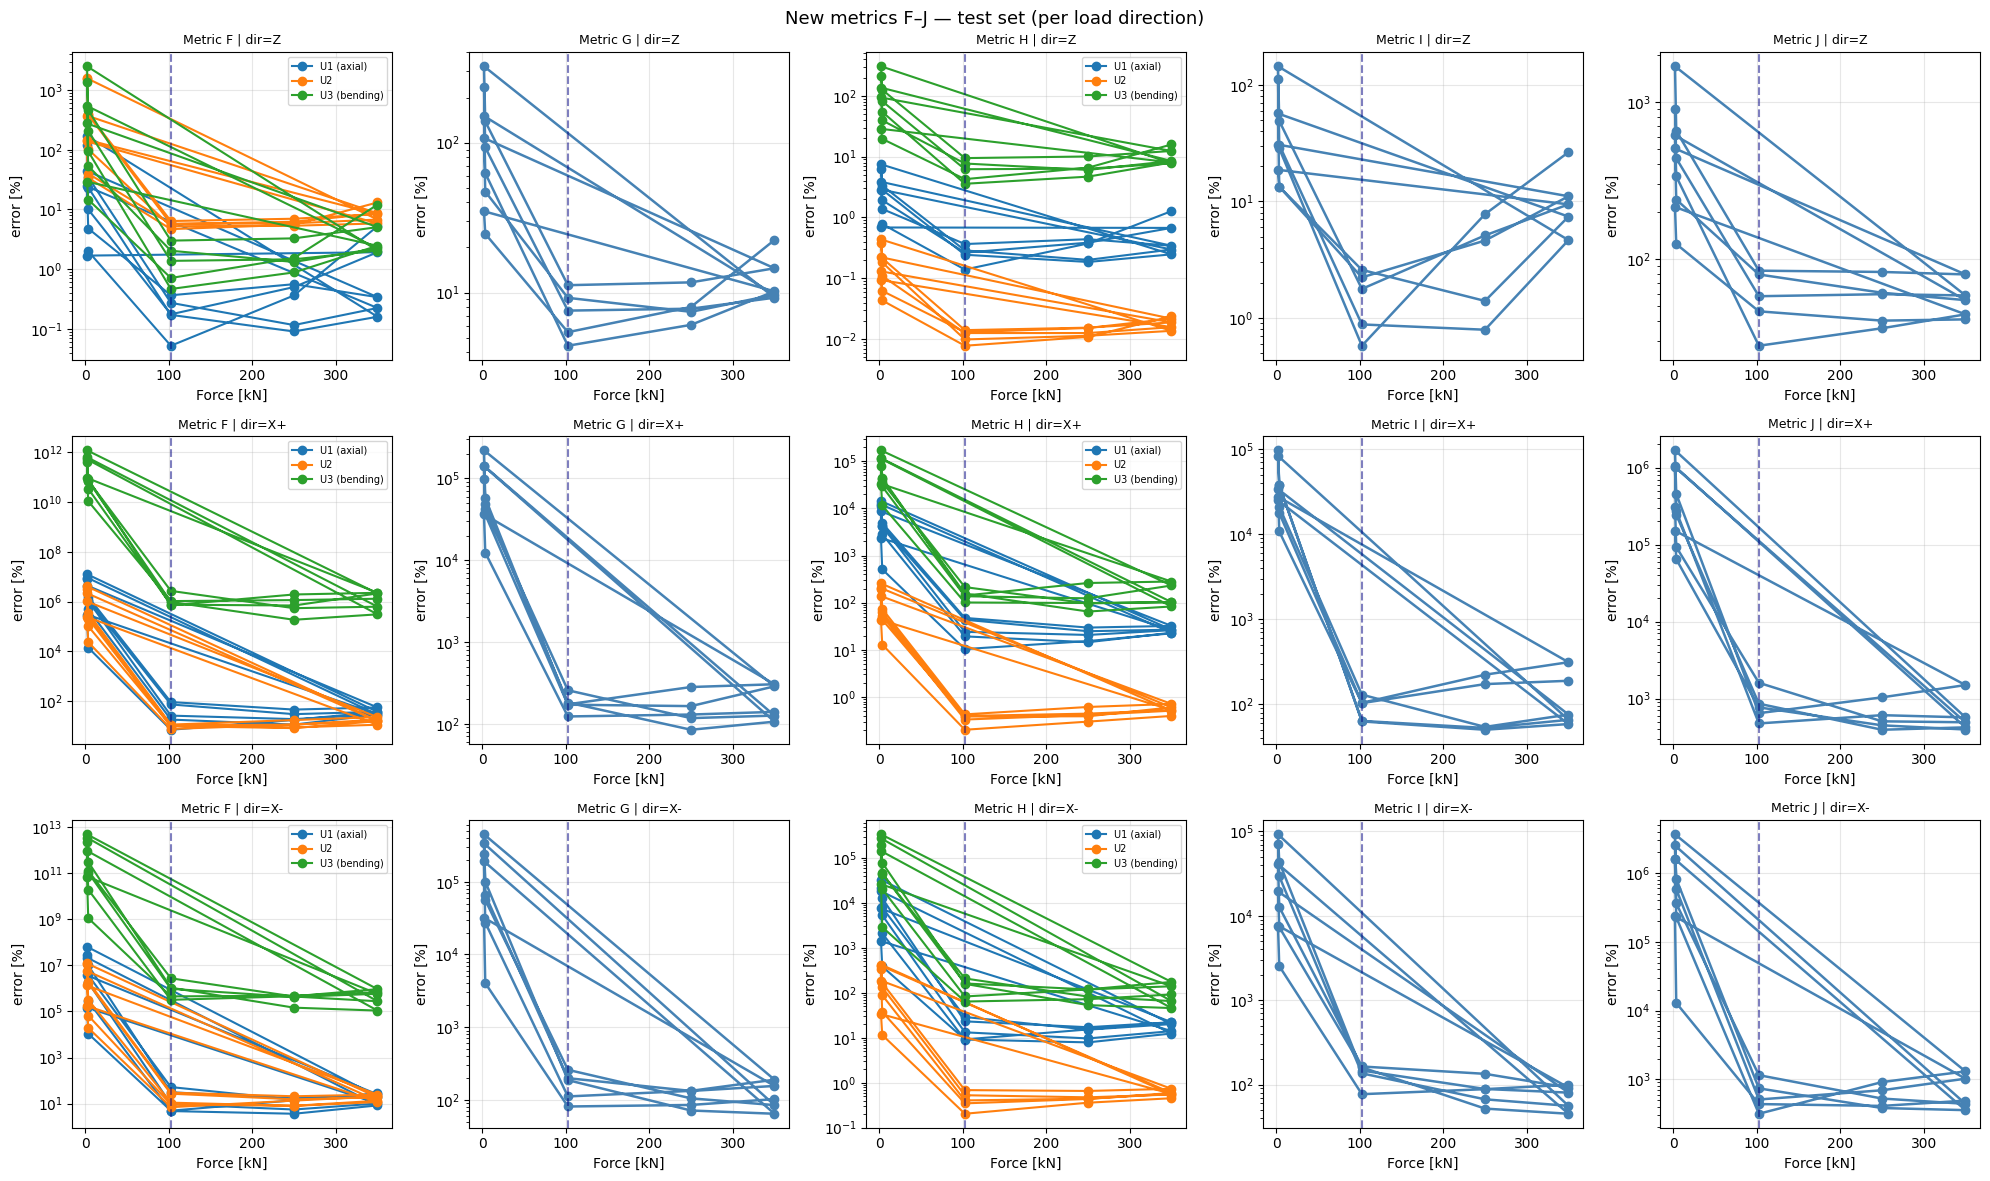

Saved → ../saves/metric_FJ_comparison.png


In [9]:
# ── Plot F–J side by side, same layout as A–E ─────────────────────────────────
DIRS = ['Z', 'X+', 'X-']
COMP_NAMES = ['U1 (axial)', 'U2', 'U3 (bending)']
NEW_METRICS = ['F', 'G', 'H', 'I', 'J']
SCALAR_METRICS = {'G', 'I', 'J'}   # single number per case

fig, axes = plt.subplots(len(DIRS), len(NEW_METRICS), figsize=(20, 12))
fig.suptitle('New metrics F–J — test set (per load direction)', fontsize=13)

for row, d in enumerate(DIRS):
    cases = [r for r in results2 if r['params']['load_dir'] == d]
    forces = [r['params']['force_N'] / 1000 for r in cases]

    for col, m in enumerate(NEW_METRICS):
        ax = axes[row, col]

        if m in SCALAR_METRICS:
            vals = [r[m] for r in cases]
            ax.plot(forces, vals, 'o-', color='steelblue', linewidth=1.8)
        else:
            for ic, cname in enumerate(COMP_NAMES):
                vals = [r[m][ic] for r in cases]
                ax.plot(forces, vals, 'o-', label=cname, linewidth=1.5)
            ax.legend(fontsize=7)

        ax.set_title(f'Metric {m} | dir={d}', fontsize=9)
        ax.set_xlabel('Force [kN]')
        ax.set_yscale('log')
        ax.axvline(x=102.5, color='navy', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.set_ylabel('error [%]')

plt.tight_layout()
out = str(ROOT / 'saves' / 'metric_FJ_comparison.png')
plt.savefig(out, dpi=120)
plt.show()
print(f'Saved → {out}')

In [10]:
# ── Summary table F–J ──────────────────────────────────────────────────────────
print(f"{'Case':<12} {'Dir':<4} {'F[kN]':>7}  {'F(U1)':>8} {'F(U3)':>8} {'G':>8} {'H(U1)':>8} {'H(U3)':>8} {'I':>8} {'J':>8}")
print('-' * 90)
for r in sorted(results2, key=lambda x: (x['params']['load_dir'], x['params']['force_N'])):
    p = r['params']
    print(
        f"{p['case_id']:<12} {p['load_dir']:<4} {p['force_N']/1000:>7.1f}  "
        f"{r['F'][0]:>8.2f} {r['F'][2]:>8.2f} "
        f"{r['G']:>8.2f} "
        f"{r['H'][0]:>8.2f} {r['H'][2]:>8.2f} "
        f"{r['I']:>8.2f} {r['J']:>8.2f}"
    )

Case         Dir    F[kN]     F(U1)    F(U3)        G    H(U1)    H(U3)        I        J
------------------------------------------------------------------------------------------
case_1505    X+       2.0  8313673.50 397217595392.00 98566.74 11071.34 80512.52 96787.62 310170.47
case_1520    X+       2.0  12548735.00 629494644736.00 142636.22 14345.74 116348.98 83253.34 1012418.75
case_1535    X+       2.0  4398449.00 516258594816.00 141431.94  8695.82 113457.91 24970.76 1035495.31
case_1550    X+       2.0  9162891.00 1186965880832.00 220964.45 12197.89 170785.52 27560.67 1678814.88
case_1565    X+       2.0  300150.94 92192595968.00 36410.00  2358.20 33331.10 33927.88 151670.86
case_1506    X+       3.5  1131679.25 72549449728.00 41998.32  4220.32 36267.86 37703.40 93408.73
case_1521    X+       3.5  1545806.75 71518633984.00 48111.25  4906.77 41063.46 37844.38 244867.00
case_1536    X+       3.5  480834.12 33931524096.00 36331.10  2839.94 29190.05 17713.41 272146.91
case_1551    X+

---
## Study: Inactive Components & Genuine Model Failure

Two separate root causes explain why metrics behave poorly for certain cases.
They are not metric design problems — they reflect physical reality and model limitations.

### Root cause 1 — Inactive displacement components

For a **Z-bending load** (force in Z), the beam bends: **U3 is active**, U1 ≈ 0, U2 ≈ 0.  
For an **X+/X- axial load** (force in X), the beam stretches: **U1 is active**, U3 ≈ 0, U2 ≈ 0.

Reporting relative error on an inactive component is physically meaningless.
If `true_U3 ≈ 0` and `pred_U3 ≈ 0`, tiny floating-point differences produce
enormous relative errors — but both are "correct" for engineering purposes.

### Root cause 2 — Genuine model failure at low axial forces

At 2 kN and 3.5 kN axial, the displacements are microscopic (< 0.01 mm).
The model has never seen such small deformations in this direction and predicts
values that are wrong in absolute terms. This is extrapolation failure, not a
metric artefact. No relative metric can make a genuinely wrong prediction look good.


In [11]:
# ── Identify active component per case based on RMS ──────────────────────────
comp_names = ["U1 (axial)", "U2", "U3 (bending)"]

print(f"  {'Case':20s}  {'RMS_U1':>8s}  {'RMS_U2':>8s}  {'RMS_U3':>8s}  {'active':>12s}")
print("-" * 72)

for r in results2:
    params = r['params']
    case_label = f"{params['load_dir']}_{params['force_N']/1e3:.1f}kN"
    rms = np.sqrt((r['true']**2).mean(axis=0))        # (3,) RMS per component
    dominant = rms.argmax()
    print(f"  {case_label:20s}  {rms[0]:8.4f}  {rms[1]:8.4f}  {rms[2]:8.4f}  {comp_names[dominant]:>12s}")


  Case                    RMS_U1    RMS_U2    RMS_U3        active
------------------------------------------------------------------------
  Z_2.0kN                 0.0136    0.0002    0.1785  U3 (bending)
  Z_3.5kN                 0.0238    0.0004    0.3124  U3 (bending)
  Z_102.5kN               0.6971    0.0111    9.1482  U3 (bending)
  Z_250.0kN               1.7003    0.0270   22.3127  U3 (bending)
  Z_350.0kN               2.3805    0.0378   31.2379  U3 (bending)
  X+_2.0kN                0.0006    0.0000    0.0000    U1 (axial)
  X+_3.5kN                0.0010    0.0000    0.0000    U1 (axial)
  X+_102.5kN              0.0289    0.0004    0.0005    U1 (axial)
  X+_250.0kN              0.0706    0.0011    0.0011    U1 (axial)
  X+_350.0kN              0.0988    0.0015    0.0016    U1 (axial)
  X-_2.0kN                0.0006    0.0000    0.0000    U1 (axial)
  X-_3.5kN                0.0010    0.0000    0.0000    U1 (axial)
  X-_102.5kN              0.0289    0.0004    0.0005    

In [12]:
# ── F(inactive) explodes — showing why inactive-component metrics are meaningless ──
print("F metric on the INACTIVE component (the one that should be near-zero):")
print("-" * 70)
print(f"  {'Case':20s}  {'inactive':>10s}  {'F(inactive) %':>16s}  {'RMS(inactive) mm':>18s}")
print("-" * 70)

for r in results2:
    params = r['params']
    case_label = f"{params['load_dir']}_{params['force_N']/1e3:.1f}kN"
    rms = np.sqrt((r['true']**2).mean(axis=0))
    dominant = rms.argmax()

    # pick an inactive component (lowest RMS)
    inactive = rms.argmin()
    f_inactive = r['F'][inactive]
    rms_inactive = rms[inactive]
    print(f"  {case_label:20s}  {comp_names[inactive]:>10s}  {f_inactive:>16.2e}  {rms_inactive:>18.4e}")


F metric on the INACTIVE component (the one that should be near-zero):
----------------------------------------------------------------------
  Case                    inactive     F(inactive) %    RMS(inactive) mm
----------------------------------------------------------------------
  Z_2.0kN                       U2          1.51e+03          2.1608e-04
  Z_3.5kN                       U2          3.82e+02          3.7814e-04
  Z_102.5kN                     U2          5.74e+00          1.1074e-02
  Z_250.0kN                     U2          5.86e+00          2.7010e-02
  Z_350.0kN                     U2          6.77e+00          3.7814e-02
  X+_2.0kN                      U2          3.13e+06          8.5657e-06
  X+_3.5kN                      U2          2.48e+05          1.4990e-05
  X+_102.5kN                    U2          1.08e+01          4.3899e-04
  X+_250.0kN                    U2          1.14e+01          1.0707e-03
  X+_350.0kN                    U2          1.61e+01     

In [13]:
# ── Absolute MAE for low-force X+/X- — proof of genuine model failure ────────
import numpy as np

print("X+/X- cases — U1 is the active component (axial displacement):")
print("-" * 78)
print(f"  {'Case':20s}  {'max|true_U1| mm':>16s}  {'MAE_U1 mm':>12s}  {'H(U1) %':>10s}  note")
print("-" * 78)

for r in results2:
    params = r['params']
    if params['load_dir'] not in ('X+', 'X-'):
        continue
    case_label = f"{params['load_dir']}_{params['force_N']/1e3:.1f}kN"
    max_u1 = np.abs(r['true'][:, 0]).max()
    mae_u1 = r['mae'][0]
    h_u1   = r['H'][0]
    note = "<< below model validity range" if max_u1 < 0.01 else ""
    print(f"  {case_label:20s}  {max_u1:16.5f}  {mae_u1:12.5f}  {h_u1:10.1f}  {note}")

print()
print("Cases flagged: the model predicts wrong absolute values.")
print("High H(U1) here is NOT a metric problem — the model is genuinely wrong.")
print("Fix: extend training data to cover small axial forces.")


X+/X- cases — U1 is the active component (axial displacement):
------------------------------------------------------------------------------
  Case                   max|true_U1| mm     MAE_U1 mm     H(U1) %  note
------------------------------------------------------------------------------
  X+_2.0kN                       0.00098       0.06260     11071.3  << below model validity range
  X+_3.5kN                       0.00171       0.04173      4220.3  << below model validity range
  X+_102.5kN                     0.05021       0.01259        43.5  
  X+_250.0kN                     0.12247       0.01753        24.9  
  X+_350.0kN                     0.17145       0.02646        26.8  
  X-_2.0kN                       0.00098       0.12447     22014.5  << below model validity range
  X-_3.5kN                       0.00171       0.07833      7922.8  << below model validity range
  X-_102.5kN                     0.05021       0.00840        29.0  
  X-_250.0kN                     0.122

In [14]:
# ── H(active component only) — recommended per-direction metric ───────────────
print("Recommended: H on active component + G as scalar headline")
print("-" * 65)
print(f"  {'Case':20s}  {'active comp':>12s}  {'H(active) %':>12s}  {'G %':>8s}")
print("-" * 65)

for r in results2:
    params = r['params']
    case_label = f"{params['load_dir']}_{params['force_N']/1e3:.1f}kN"
    rms = np.sqrt((r['true']**2).mean(axis=0))
    dominant = rms.argmax()
    h_active = r['H'][dominant]
    g_val    = r['G']
    valid    = "" if (params['load_dir'] in ('Xp', 'Xm') and rms[0].max() < 0.01) else ""
    print(f"  {case_label:20s}  {comp_names[dominant]:>12s}  {h_active:12.2f}  {g_val:8.2f}")


Recommended: H on active component + G as scalar headline
-----------------------------------------------------------------
  Case                   active comp   H(active) %       G %
-----------------------------------------------------------------
  Z_2.0kN               U3 (bending)        215.52    236.48
  Z_3.5kN               U3 (bending)         81.61     93.01
  Z_102.5kN             U3 (bending)          6.22      7.58
  Z_250.0kN             U3 (bending)          6.35      7.81
  Z_350.0kN             U3 (bending)          7.80      9.25
  X+_2.0kN                U1 (axial)      11071.34  98566.74
  X+_3.5kN                U1 (axial)       4220.32  41998.32
  X+_102.5kN              U1 (axial)         43.52    256.73
  X+_250.0kN              U1 (axial)         24.85    117.19
  X+_350.0kN              U1 (axial)         26.79    125.92
  X-_2.0kN                U1 (axial)      22014.47  236970.34
  X-_3.5kN                U1 (axial)       7922.77  56049.59
  X-_102.5kN    

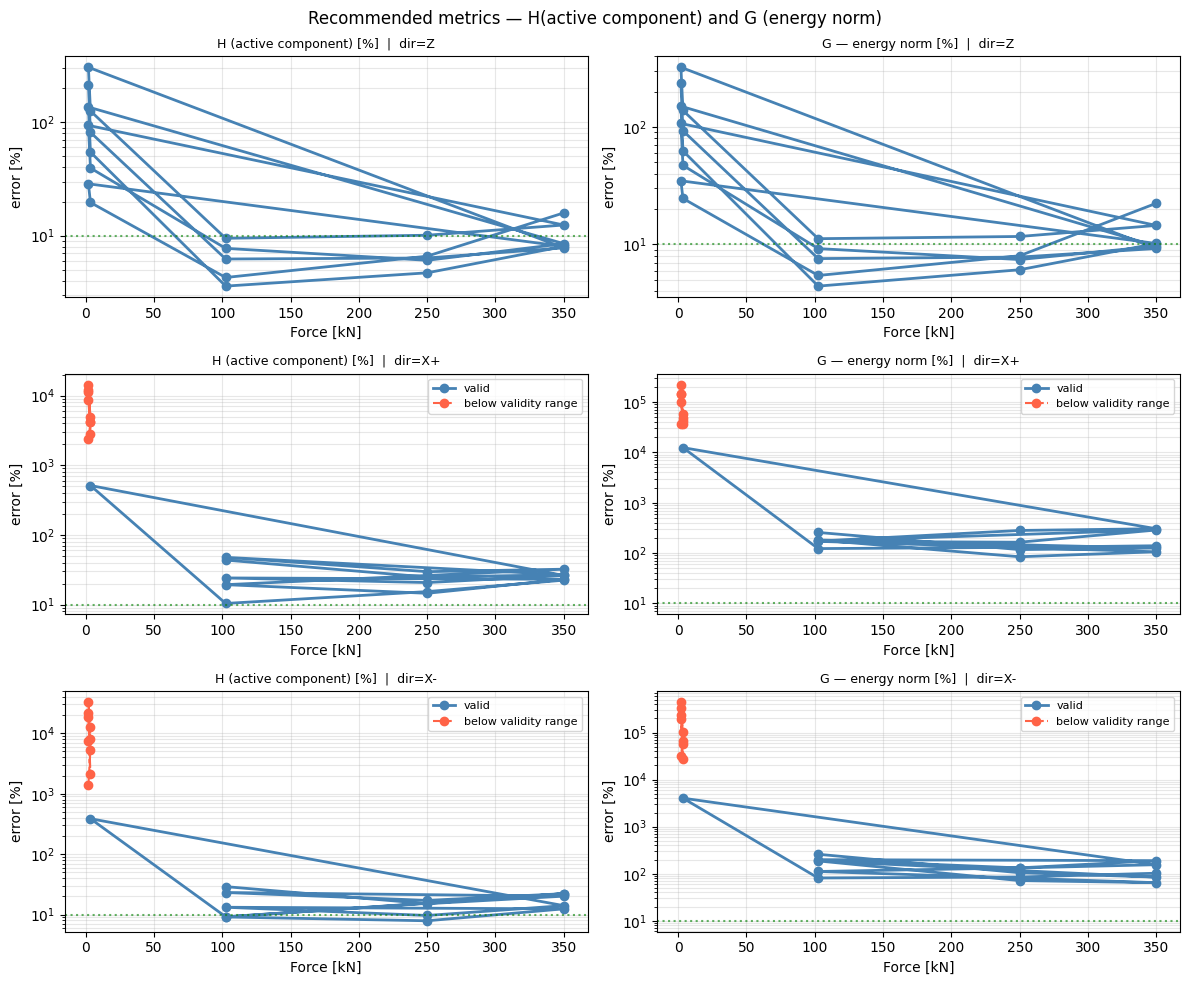

Saved → ../saves/recommended_metrics_H_G.png


In [15]:
# ── Recommended metrics: H(active) and G, plotted per load direction ──────────
import numpy as np
import matplotlib.pyplot as plt

DIRS = ['Z', 'X+', 'X-']
LOW_FORCE_THRESHOLD = 0.01  # mm — below this, flag as model failure

fig, axes = plt.subplots(len(DIRS), 2, figsize=(12, 10), sharex='row')
fig.suptitle('Recommended metrics — H(active component) and G (energy norm)', fontsize=12)

for row, d in enumerate(DIRS):
    cases = [r for r in results2 if r['params']['load_dir'] == d]
    forces = np.array([r['params']['force_N'] / 1000 for r in cases])

    # determine active component per case (argmax RMS)
    h_active = []
    g_vals   = []
    is_valid = []
    for r in cases:
        rms = np.sqrt((r['true']**2).mean(axis=0))
        dom = rms.argmax()
        h_active.append(r['H'][dom])
        g_vals.append(r['G'])
        max_disp = np.abs(r['true']).max()
        # flag low-force axial as invalid
        if d in ('X+', 'X-') and np.abs(r['true'][:, 0]).max() < LOW_FORCE_THRESHOLD:
            is_valid.append(False)
        else:
            is_valid.append(True)

    h_active = np.array(h_active)
    g_vals   = np.array(g_vals)
    is_valid = np.array(is_valid)

    for col, (vals, title) in enumerate([(h_active, 'H (active component) [%]'),
                                          (g_vals,   'G — energy norm [%]')]):
        ax = axes[row, col]

        # valid cases — solid line
        if is_valid.any():
            ax.plot(forces[is_valid], vals[is_valid], 'o-',
                    color='steelblue', linewidth=2, label='valid')

        # flagged cases — red markers, dashed
        if (~is_valid).any():
            ax.plot(forces[~is_valid], vals[~is_valid], 'o--',
                    color='tomato', linewidth=1.5, label='below validity range')
            ax.legend(fontsize=8)

        ax.set_title(f'{title}  |  dir={d}', fontsize=9)
        ax.set_xlabel('Force [kN]')
        ax.set_ylabel('error [%]')
        ax.set_yscale('log')
        ax.grid(True, which='both', alpha=0.3)
        ax.axhline(y=10, color='green', linestyle=':', alpha=0.6, label='10% target')

plt.tight_layout()
out = str(ROOT / 'saves' / 'recommended_metrics_H_G.png')
plt.savefig(out, dpi=120)
plt.show()
print(f'Saved → {out}')


## Metric Recommendation

| Metric | Scope | Role |
|--------|-------|------|
| **G** (energy norm) | scalar, all 3 components | headline summary — one number per case |
| **H(active)** | scalar, active component only | interpretable per-direction accuracy |

**Active component rule** (automated, from RMS):
- `argmax(RMS per component)` → U1 for X+/X- loads, U3 for Z loads

**Do not report:**
- Relative error on inactive components (U3 for axial loads, U1 for bending loads) — the denominator is near-zero and the result is meaningless
- F, A, B, C, D, E on inactive components for the same reason

**Flagging low-force axial cases:**
```
if max|true_U1| < 0.01 mm → flag as "below model validity range"
```
These cases are extrapolation failures. The fix is more training data at low forces,
not a different metric.
